# Work in Progress

# Introduction
In this project we will be constructing a table from a 2D image. For this implementation we will be estimating the three dimensional coordinates in the world from our camera parameters and two dimensional cooridnates on the image in respects of the three dimensional coordinates in the world.

# The Math
To begin, we define the Intrinsic Parameter Matrix $ \Lambda $.
$$
\Lambda
=
\begin{bmatrix}
\phi_{xj} & \gamma_j & \delta_{xj} \\
0 & \phi_{yj} & \delta_{yj} \\
0 & 0 & 1
\end{bmatrix}
$$

The model relates homogeneous image coordinates $[x_j, y_j, 1]^T $ from world coordinates $[u, v, w, 1]^T$ via intrinsic and extrinsic (rotation and translation) parameters, scaled by the factor $ \lambda_j $.

$$
\lambda_j
\begin{bmatrix}
x_j \\
y_j \\
1
\end{bmatrix}
=
\Lambda
\begin{bmatrix}
\omega_{11j} & \omega_{12j} & \omega_{13j} & \tau_{xj} \\
\omega_{21j} & \omega_{22j} & \omega_{23j} & \tau_{yj} \\
\omega_{31j} & \omega_{32j} & \omega_{33j} & \tau_{zj}
\end{bmatrix}
\begin{bmatrix}
u \\
v \\
w \\
1
\end{bmatrix}
$$

Our objective is to solve for the world coordinates. We multiply both sides by $ \Lambda^{-1} $, which results in the normalized image coordinates $x'_j$ and $y'_j$.

$$
\begin{bmatrix}
\lambda_j x'_j \\
\lambda_j y'_j \\
\lambda_j
\end{bmatrix}
=
\begin{bmatrix}
\omega_{11j} & \omega_{12j} & \omega_{13j} & \tau_{xj} \\
\omega_{21j} & \omega_{22j} & \omega_{23j} & \tau_{yj} \\
\omega_{31j} & \omega_{32j} & \omega_{33j} & \tau_{zj}
\end{bmatrix}
\begin{bmatrix}
u \\
v \\
w \\
1
\end{bmatrix},
$$

To handle the homogeneous coordinate scaling factor $ \lambda_j $, we substitute $ \lambda_j $ with the last row of the matrix multiplication on the right side of the equation, cancelling out the last row for both equations.

$$
\lambda_j = \omega_{31j}u + \omega_{32j}v + \omega_{33j}w + \tau_{zj}
$$

$$
\begin{bmatrix}
(\omega_{31j}u + \omega_{32j}v + \omega_{33j}w + \tau_{zj})x'_j \\
(\omega_{31j}u + \omega_{32j}v + \omega_{33j}w + \tau_{zj})y'_j
\end{bmatrix}
=
\begin{bmatrix}
\omega_{11j} & \omega_{12j} & \omega_{13j} & \tau_{xj} \\
\omega_{21j} & \omega_{22j} & \omega_{23j} & \tau_{yj}
\end{bmatrix}
\begin{bmatrix}
u \\
v \\
w \\
1
\end{bmatrix}
$$

In this form, we can isolate $\tau$ to one side of the equation.

$$
\begin{bmatrix}
\omega_{31j}x'_j - \omega_{11j} & \omega_{32j}x'_j - \omega_{12j} & \omega_{33j}x'_j - \omega_{13j} \\
\omega_{31j}y'_j - \omega_{21j} & \omega_{32j}y'_j - \omega_{22j} & \omega_{33j}y'_j - \omega_{23j}
\end{bmatrix}
\begin{bmatrix}
u \\
v \\
w
\end{bmatrix}
=
\begin{bmatrix}
\tau_{xj} - \tau_{zj}x'_j \\
\tau_{yj} - \tau_{zj}y'_j
\end{bmatrix}
$$

Now we can replace each element of the matrix with their respective $ a_j, b_j, c_j, d_j, e_j, $ and $ f_j $ for cleaner notation.
$$
\begin{bmatrix}
a_j & b_j & c_j \\
d_j & e_j & f_j
\end{bmatrix}
\begin{bmatrix}
u \\
v \\
w
\end{bmatrix}
=
\begin{bmatrix}
g_j \\
h_j
\end{bmatrix}
$$
By stacking $ J $ cameras, the equation can support information from multiple perspectives.
$$
\begin{bmatrix}
a_1 & b_1 & c_1 \\
d_1 & e_1 & f_1 \\
a_2 & b_2 & c_2 \\
d_2 & e_2 & f_2 \\
\vdots & \vdots & \vdots \\
a_J & b_J & c_J \\
d_J & e_J & f_J
\end{bmatrix}
\begin{bmatrix}
u \\
v \\
w
\end{bmatrix}
=
\begin{bmatrix}
g_1 \\
h_1 \\
g_2 \\
h_2 \\
\vdots \\
g_J \\
h_J
\end{bmatrix},
$$
Furthermore, we replace those matrices with the following notation for even cleaner notation.
$$
A\mathbf{w} = \mathbf{b},
$$
Finally, using Moore-Penrose Pseudoinverse $ A^\dagger $ isolates the world coordinates $ \mathbf{\hat{w}} $.
$$
\mathbf{\hat{w}} = A^\dagger\mathbf{b},
$$


# Pseudo Matrices
A core component of Pseudo Matrices is Single Value decompostion (SVD). It's purpose is dividing a linear transformation into multiple components each with its own attributes:

$$M = U \Sigma V^T$$

Were *Vᵀ* is in charge of rotating or tilting to orthogonal unit vectors (change of basis), the Σ is a rectangular transformation matrix (e.g transfroming a 3D shape to a 2D) and U represents the original directions before the *Vᵀ* transformation in respects of Σ. The graphics below are from this [video](https://www.youtube.com/watch?v=vSczTbgc8Rc).


Pseudo Matrices uses variation of:

$$A^\dagger = V \Sigma^{T} U^{T}$$

The biggest difference is that we are transposing the Σ. Due to change of  dimensions the orthogonal matrices (U and V) had to change order because at its essence what a rectangular transposed matrix is grabbing a 3D space and squishing it into a single line. This is useful because how the 3D world points estimator works is using a single line that goes through the x and y coordinates in an image to estimate the w coordinates.

In [1]:
import os
import imageio
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import gdown

In [3]:
def json_read(filename):
  try:
      with open(os.path.abspath(filename)) as f:
          data = json.load(f)
      return data
  except:
      raise ValueError("Unable to read JSON {}".format(filename))


#Extracts the camera parameters and returns np arrays as
#intrinsic(Lambda)/(N, 3, 3), rotation(Omega)/(N, 3, 3),
# translation(tau)/(N, 3, 1), with N being amount of cameras.
def all_camera_parameters(cameras, pathname):

  #Reads the json file containing the calibration data
  calibration = json_read("/{}".format(pathname) + "/calibration.json")

  #Declares future stacked arrays
  Lambda_stacked, Omega_stacked, tau_stacked = [],[],[]

  for view in cameras:

  #Gets the calibration matrices from each cameras
    Lambda_stacked.append(np.array(calibration[view]['K']))     #Intrinsic params.
    Omega_stacked.append(np.array(calibration[view]['R']))      #Rotation

    #Addresses nuances of different matrices implementation
    #(ex (3,1) vs (3,))
    tau_stacked.append(np.array(calibration[view]['t']).reshape(3,1))      #Translation

  #Returns the stacked arrays as np arrays
  return np.array(Lambda_stacked), np.array(Omega_stacked), np.array(tau_stacked)


#Estimates the points in 3D space
#Required dimensions for np arrays, with N being the amount of cameras and P the amount of points
#xy = (N, P >= 2, 2) (Lambda = (N, 3, 3)
#Omega = (N, 3, 3), tau = (N, 3, 1)
def estimated3Dpoints(xy, Lambda, Omega, tau):

  #Converts into homogeneous coordinates, (6, 4, 2) -> (6, 4, 3)
  column_ones = np.ones((xy.shape[0], xy.shape[1], 1))
  XY_homog = np.concatenate([xy, column_ones], axis=2)

  #Matrix mulitplication of xy with inverse of lambda
  #= (6, 4, 3) = (6, 4, 3) @ (6, 3, 3)
  xy_norm_homog = XY_homog @ np.linalg.inv(Lambda).transpose(0, 2, 1)

  #Normalizes homogeneous coordinate by dividing the z axis in xy_norm_homog
  #to cancel it out
  xy_norm = xy_norm_homog[:, :, :2] / xy_norm_homog[:,:,2:3]

  #Converts back into cartesian coordinates shape (6, 4, 2, 1)
  xy_norm = xy_norm.reshape(XY_homog.shape[0],XY_homog.shape[1], 2, 1)

  #We need match Omega's dimension by adding new axis to construct Matrix A
  #Omega[all cameras, all points, both x y coodinates,
  # last row, all columns] = (6, 1, 1, 3)
  A = xy_norm * Omega[:, np.newaxis, np.newaxis, 2, :]

  #Rearranging to isolate tau to finalize matrix A
  A = A - Omega[:, np.newaxis, :2, :]

  #Constructs Matrix B
  #tau[all cameras, all points, third row, every column]
  # - tau[all cameras, all points, third to fourth row, every column]
  B = tau[:,np.newaxis, :2,:] - (xy_norm*tau[:, np.newaxis, 2:3,:])

  #We swap out cameras and points columns to align with the math.
  #We flatten out cameras and equation vectors (what became of
  #the extrinsic and intrinsic parameters) because each point requires
  #its own system of equation.
  A_final = A.transpose(1, 0, 2, 3).reshape(xy.shape[1], xy.shape[0] * 2, 3)
  B_final = B.transpose(1, 0, 2, 3).reshape(xy.shape[1], xy.shape[0] * 2, 1)

  #We compute the Pseudo inverse
  w = np.linalg.pinv(A_final) @ B_final

  #Returns shape (4,3,1)
  return w

def plotReconstructedObject(w_hat):
    #Extract coordinates
    x = w_hat[:, 0]
    y = w_hat[:, 1]
    z = w_hat[:, 2]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x, y, z, c=z, cmap='viridis', marker='o', s=50, alpha=0.9)

    fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5, pad=0.1, label='Z-Depth')

    ax.plot(np.append(x, x[0]), np.append(y, y[0]), np.append(z, z[0]), c='black', alpha=0.5)

    ax.grid(False)

    z_floor = np.min(z) - np.ptp(z) * 0.2

    ax.scatter(x, y, np.full_like(z, z_floor), c='gray', marker='o', alpha=0.3)
    ax.plot(np.append(x, x[0]), np.append(y, y[0]), np.full_like(np.append(z, z[0]), z_floor), c='gray', alpha=0.3)

    ax.set_zlim(z_floor, np.max(z))

    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

    # ax.view_init(elev=45, azim=45)

    plt.show()

#Calculates the error
def reprojectionError(xy, Lambda, Omega, tau, w_est):

  #We need to add extra one to match our equation
  column_ones = np.ones((w_est.shape[0], 1, w_est.shape[2]))
  w_est_homogenous = np.concatenate([w_est, column_ones], axis=1)

  #Constructs matrix for our equation
  ome_tau = np.concatenate([Omega, tau], axis = 2)

  #
  xy_homog = Lambda[:, np.newaxis, :, :] @ ome_tau[:, np.newaxis, :, :] @ w_est_homogenous[np.newaxis, :, :, :]

  xy_homog = xy_homog / xy_homog[:,:, 2:3, :]

  xy_est = xy_homog[:,:, :2, 0]

  return np.mean((xy-xy_est)**2)

/content/soldiers_bc_epfl.tar.gz


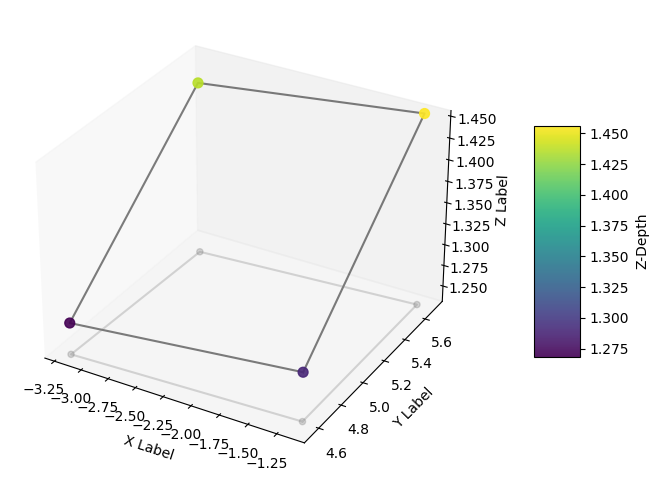

Reprojection Error: 25357.933184486435


In [4]:
filename= 'soldiers_bc_epfl.tar.gz'
pathname = 'content'
url = 'https://drive.google.com/uc?id=17rwFmew4XoQOoDDGs7yO2ovBmMZ5Qcf7'
cameras = ['3_2', '3_4', '6_1', '6_3', '6_4', '6_5']
download = True
points = 4

if download:
  #Gets the camera information
  print(gdown.download(url, "/{}/".format(pathname), quiet = True))
  #Extracts the contents of file .tar
  os.system('tar -xvf ' + "/{}/{} ".format(pathname,filename) + '-C /{}/'.format(pathname))

#XY coordinates need to be in the same order as the cameras,
#and the points gotta match. Ex: [1196,320], [816, 306]
#are the same corner of the table, in different cameras persepctives
XY = np.array([
    [1196, 320], [1274, 318], [1180, 296], [1112, 295],

    [816, 306], [799, 319], [968, 334], [977, 319],

    [1240, 504], [1316, 506], [1307, 359], [1232, 356],

    [904, 260], [928, 230], [742, 222], [706, 250],

    [739, 268], [733, 244], [582, 244], [580, 267],

    [996, 408], [1058, 433], [1231, 418], [1169, 395]
])

#XY(cameras, points, axis per point)
XY = XY.reshape(len(cameras), points, 2)


Lambda, Omega, Tau = all_camera_parameters(cameras, pathname)


allwestimated = estimated3Dpoints(XY, Lambda, Omega, Tau)

#will plot the reconstructed object
plotReconstructedObject(np.array(allwestimated))

print("Reprojection Error: " + str(reprojectionError(XY, Lambda, Omega, Tau, allwestimated)))




In my first attempt at this task, my reprojection error was around 80 million. Initially, I thought this was due to scaling, but upon further inspection, my math was completely wrong because it estimated per camera directly and then averaged the results. In reality, we needed to use the stacked matrices so the model could account for the entire system of equations. This, alongside other tweaks, decreased my reprojection error from 2315931076561 to 25357, so we are getting there! Our figure does resemble the shape of the table and the lengths of the edges seem reasonable (it’s a rectangle so two sides must be larger than the other two and change in the z axis is minimal because well the table is flat).

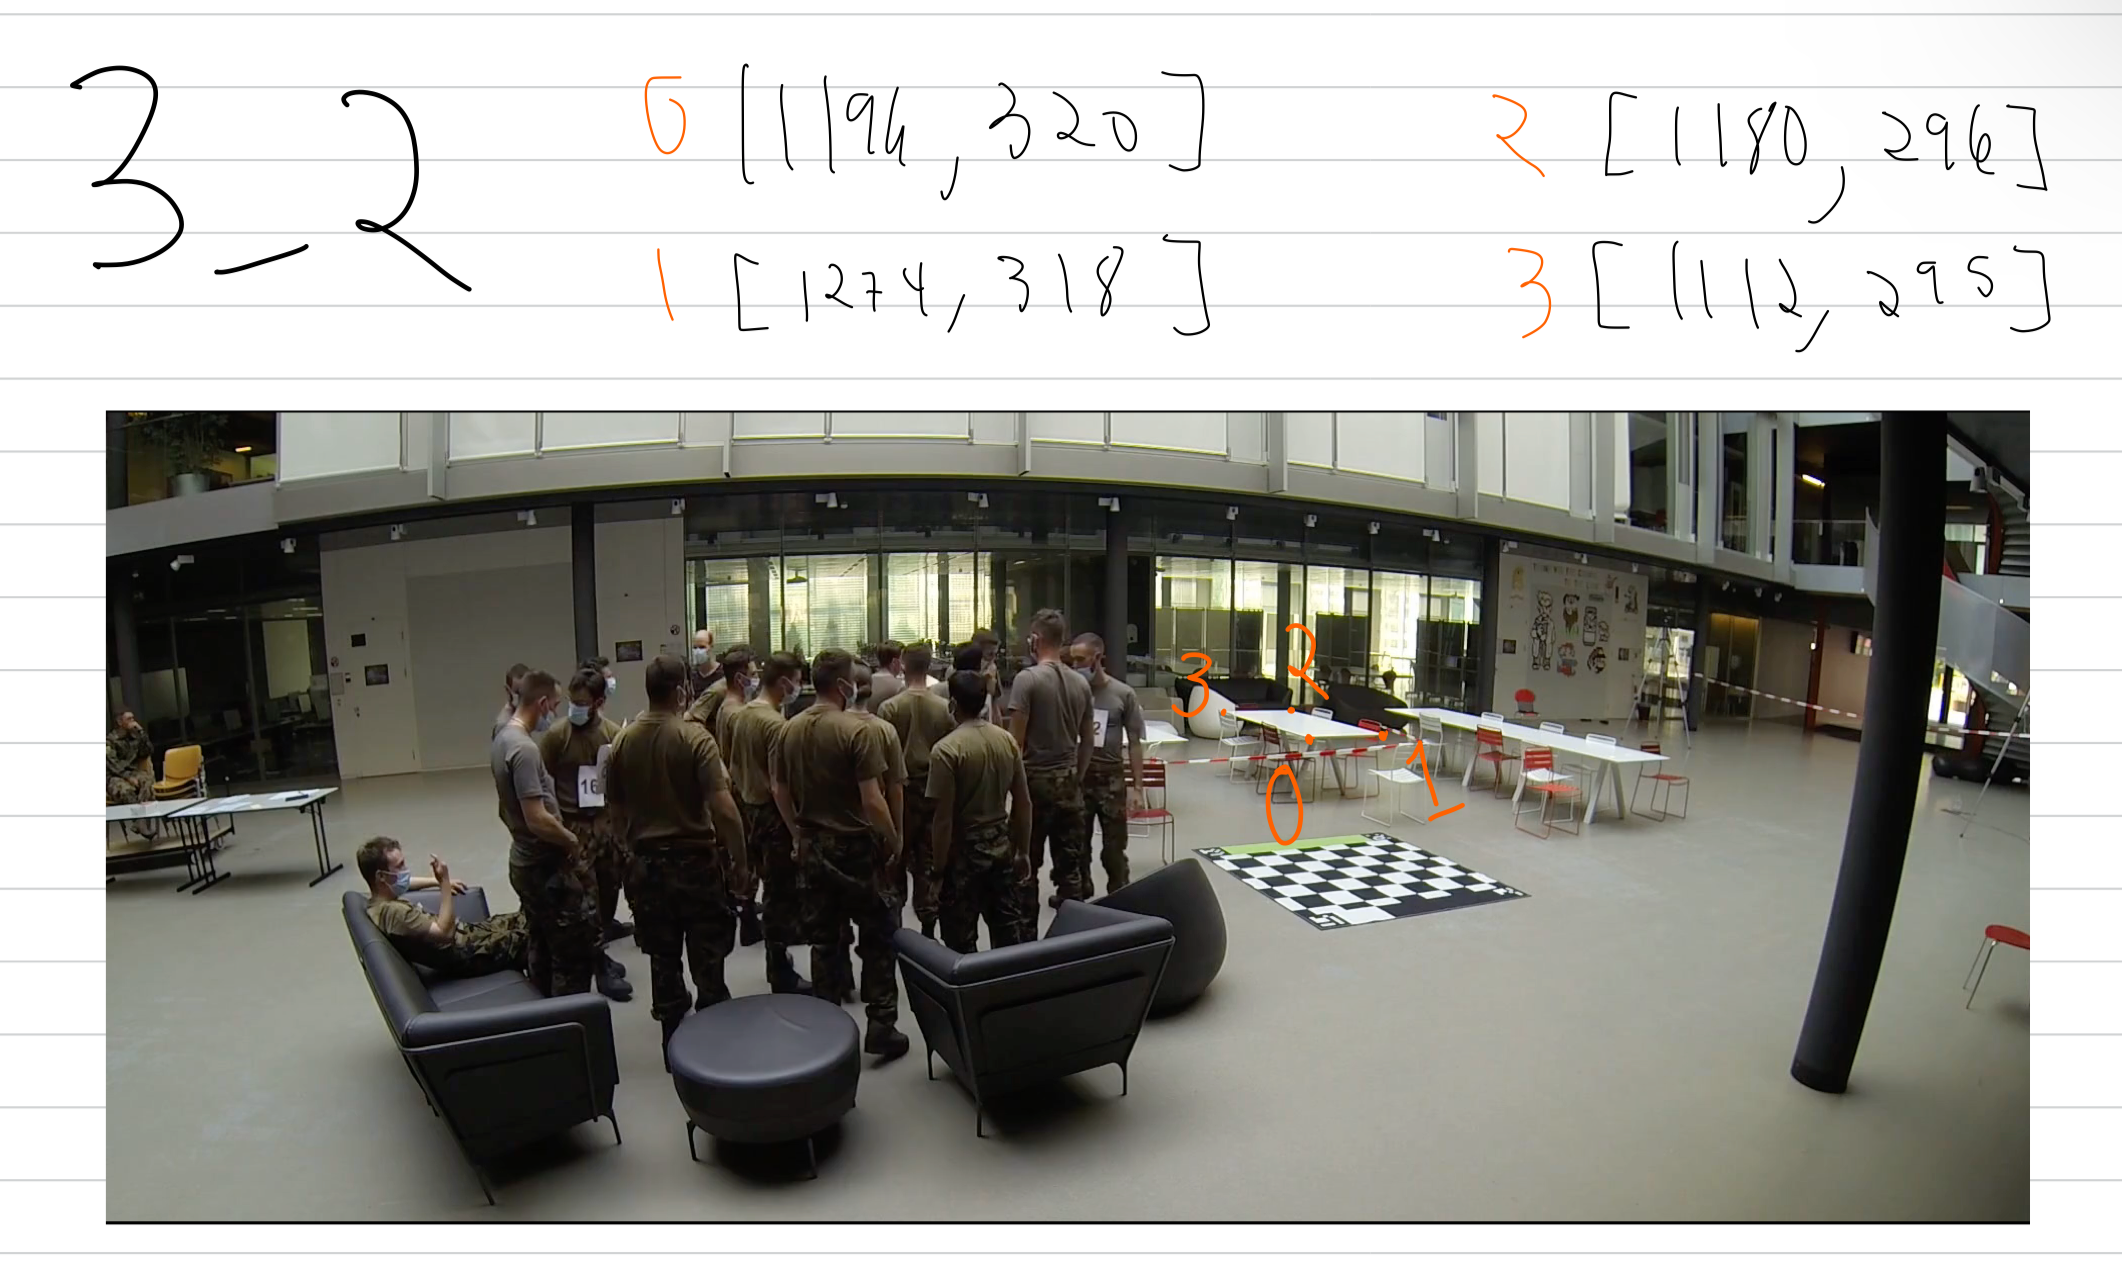